In [1]:
#Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sympy.physics.mechanics import dynamicsymbols
from scipy.integrate import solve_ivp
from scipy.linalg import solve_continuous_are
import matplotlib.animation as animation

In [102]:
#System parameters
m = 1.0
M = 5.0
g = 9.81
L = 2.0
F_MAX = 20.0 

#Solving for gain matrix for LQR by hand
A = np.array([[0, 1, 0, 0],
              [0, 0, m*g/M, 0],
              [0, 0, 0, 1],
              [0, 0, (M+m)*g/(M*L), 0]])
 
B = np.array([0, 1/M, 0, 1/(M*L)]).reshape(-1, 1)

Q = np.diag([0.1, 0.1, 50, 400])

R = np.array([[1/F_MAX**2]])

P = solve_continuous_are(A, B, Q, R)
K = np.linalg.inv(R) @ B.T @ P
K = K.flatten()

In [142]:
kx = 0.3

def lqr_controller(t, state):
    error = state - np.array([0, 0, np.pi, 0])  # Desired state is [x=0, x_dot=0, theta=pi, theta_dot=0]
    error[2] = (error[2] + np.pi) % (2 * np.pi) - np.pi  # Wrap error to [-pi, pi]
    if abs(error[2]) > np.radians(15) and abs(state[3]) < np.radians(100):  # If the angle error is large and angular velocity is small
        F_swing = -F_MAX * np.sign(state[3] * np.cos(state[2]))  # Apply a small force to reduce the angle error
        F_center = -kx * state[0]
        F = F_swing + F_center
    else:
        F = -K @ error
    F = np.clip(F, -F_MAX, F_MAX)
    return F


def derivatives(t, state):
    x, x_dot, theta, theta_dot = state
    F = lqr_controller(t, state)
    s, c = np.sin(theta), np.cos(theta)
    denom = M + m * s**2
    x_ddot = (F + m * s * (L * theta_dot**2 + g * c)) / denom
    theta_ddot = (-(M + m)*g*s - F*c - m*L*s*c*theta_dot**2) / (L * denom)
    return [x_dot, x_ddot, theta_dot, theta_ddot]

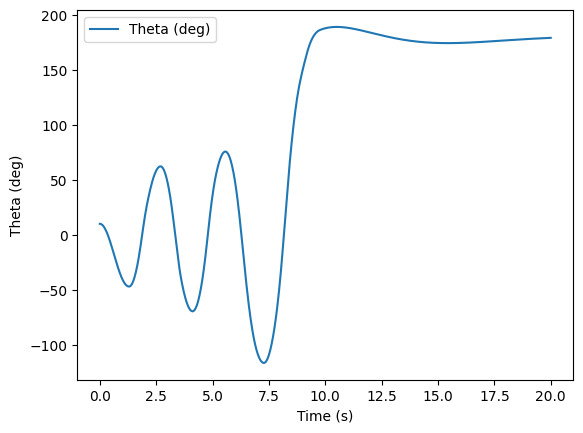

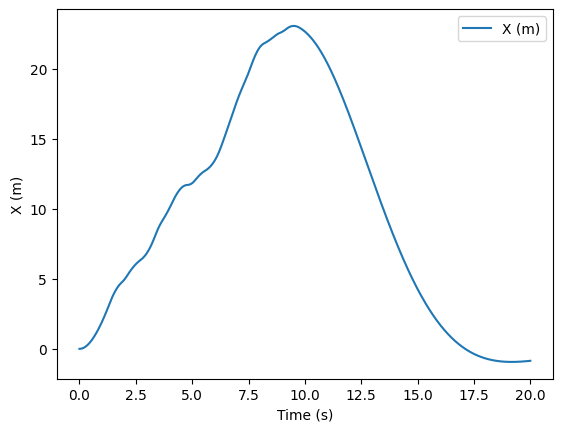

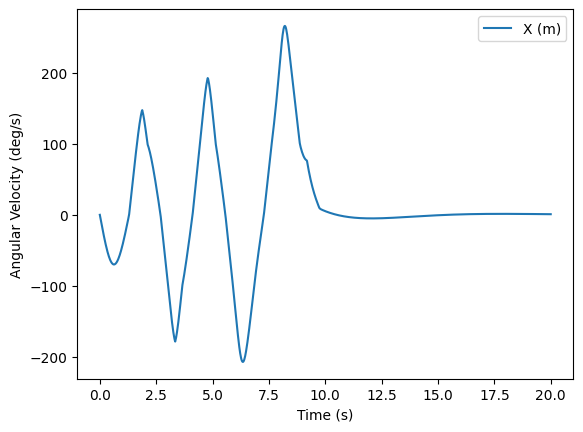

In [143]:
theta0 = np.radians(10)
theta_dot0 = np.radians(0)
x0 = 0.0
x_dot0 = 0.0
state0 = [x0, x_dot0, theta0, theta_dot0]
integral_error = 0.0

t_end = 20
fps = 50
t_eval = np.linspace(0, t_end, t_end*fps)

sol = solve_ivp(derivatives, [0, t_end], state0, t_eval=t_eval, rtol=1e-9, atol=1e-9)
x, x_dot, theta, theta_dot = sol.y
t = sol.t

plt.plot(t, np.degrees(theta), label='Theta (deg)')
plt.xlabel('Time (s)')
plt.ylabel('Theta (deg)')
plt.legend()
plt.show()

plt.plot(t, x, label='X (m)')
plt.xlabel('Time (s)')
plt.ylabel('X (m)')
plt.legend()
plt.show()

plt.plot(t, np.degrees(theta_dot), label='X (m)')
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity (deg/s)')
plt.legend()
plt.show()

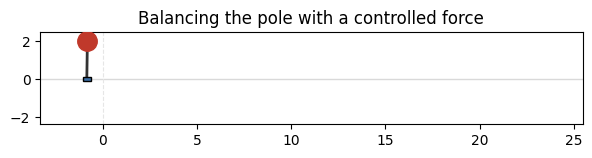

In [144]:
bob_x = x + L * np.sin(theta)
bob_y = -L * np.cos(theta)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.set_xlim(x.min() - L - 0.4, x.max() + L + 0.4)
ax.set_ylim(-L - 0.4, L + 0.5)
ax.set_aspect('equal')
ax.axhline(0, color='0.85', lw=1)
ax.axvline(0, color='0.9', lw=0.8, ls='--')      # cart target position
ax.set_title("Balancing the pole with a controlled force")
 
cart_w, cart_h = 0.4, 0.2
cart = plt.Rectangle((0, -cart_h/2), cart_w, cart_h, fc='#3b6ea5', ec='k', zorder=3)
ax.add_patch(cart)
rod,   = ax.plot([], [], '-', color='#333', lw=2, zorder=2)
bob,   = ax.plot([], [], 'o', color='#c0392b', ms=14, zorder=4)
 
def animate(i):
    cx = x[i]
    cart.set_xy((cx - cart_w/2, -cart_h/2))
    rod.set_data([cx, bob_x[i]], [0, bob_y[i]])
    bob.set_data([bob_x[i]], [bob_y[i]])
    scale = 0.06
    return cart, rod, bob

ani = animation.FuncAnimation(fig, animate, frames=len(t_eval),
                              interval=1000/fps, blit=True)

ani.save("cart_pole_control_LQR.gif", writer=animation.FFMpegWriter(fps=fps))